In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rc
import folium
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time
import random
from datetime import datetime
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

import sys
modules = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'folium': 'folium',
    'beautifulsoup4': 'bs4',
    'selenium': 'selenium',
    'lxml': 'lxml'
}
print("=" * 50)
print("모듈 설치 확인")
print("=" * 50)
for package, import_name in modules.items():
    try:
        module = __import__(import_name)
        version = getattr(module, '__version__', 'unknown')
        print(f"✓ {package:20s} {version}")
    except ImportError:
        print(f"✗ {package:20s} 설치 안됨")
print("=" * 50)

모듈 설치 확인
✓ numpy                2.3.5
✓ pandas               2.3.3
✓ matplotlib           3.10.8
✓ seaborn              0.13.2
✓ folium               0.20.0
✓ beautifulsoup4       4.14.3
✓ selenium             4.39.0
✓ lxml                 6.0.2


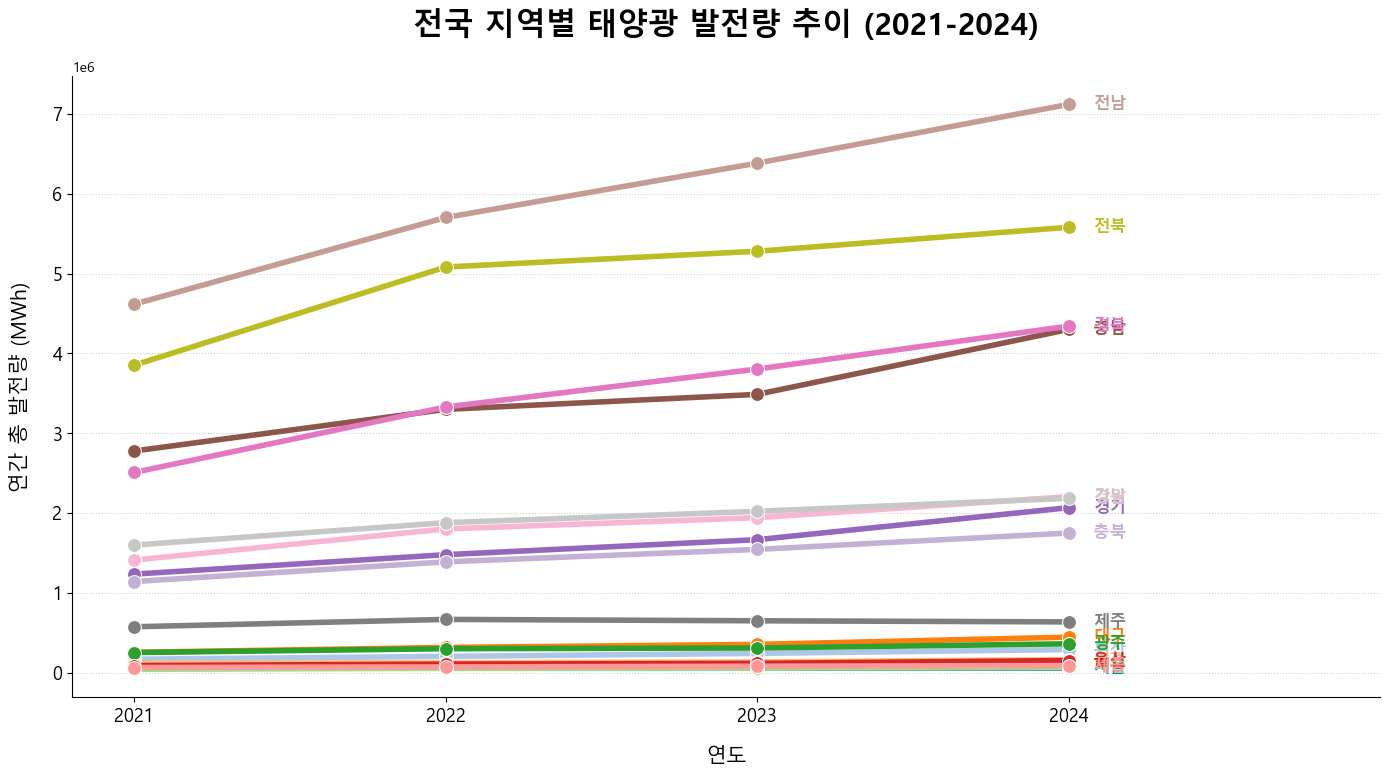

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 (파일명은 실제 경로에 맞게 수정해주세요)
df = pd.read_csv('U통합자료+누적설비용량+누적발전소개수.csv', encoding='cp949')

# 데이터 전처리
month_cols = ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']
for col in month_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '').astype(float)
df['연간총발전량'] = df[month_cols].sum(axis=1)

# --- PPT 최적화 설정 시작 ---
# 16:9 비율로 사이즈 조정 (PPT 와이드 슬라이드 기준)
plt.figure(figsize=(14, 7.875)) 

# 선 굵기와 마커 사이즈 키우기
palette = sns.color_palette("tab20", len(df['구분'].unique()))
plot = sns.lineplot(data=df, x='연도', y='연간총발전량', hue='구분', 
                    palette=palette, marker='o', markersize=10, linewidth=4, legend=False)

# 선 끝에 지역명 표시 (텍스트 크기 키움)
for line, name in zip(plot.lines, df['구분'].unique()):
    y_data = line.get_ydata()
    if len(y_data) > 0:
        last_y = y_data[-1]
        # x축 끝 지점 뒤에 텍스트가 잘리지 않도록 배치
        plt.text(2024.08, last_y, name, color=line.get_color(), 
                 fontsize=12, fontweight='bold', va='center')

# 차트 장식 제거 및 가독성 향상
plt.title('전국 지역별 태양광 발전량 추이 (2021-2024)', fontsize=22, pad=30, fontweight='bold')
plt.xlabel('연도', fontsize=15, labelpad=15)
plt.ylabel('연간 총 발전량 (MWh)', fontsize=15, labelpad=15)

# 테두리(Spines) 중 위쪽과 오른쪽 제거하여 깔끔하게 표현
sns.despine()

plt.xticks([2021, 2022, 2023, 2024], fontsize=13)
plt.yticks(fontsize=13)
plt.xlim(2020.8, 2025.0) # 지역명이 들어갈 오른쪽 여백 확보
plt.grid(True, axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()

# 그래프 저장 (PPT 삽입 시 고해상도 유지)
# plt.savefig('solar_trend_graph.png', dpi=300, bbox_inches='tight')
plt.show()              

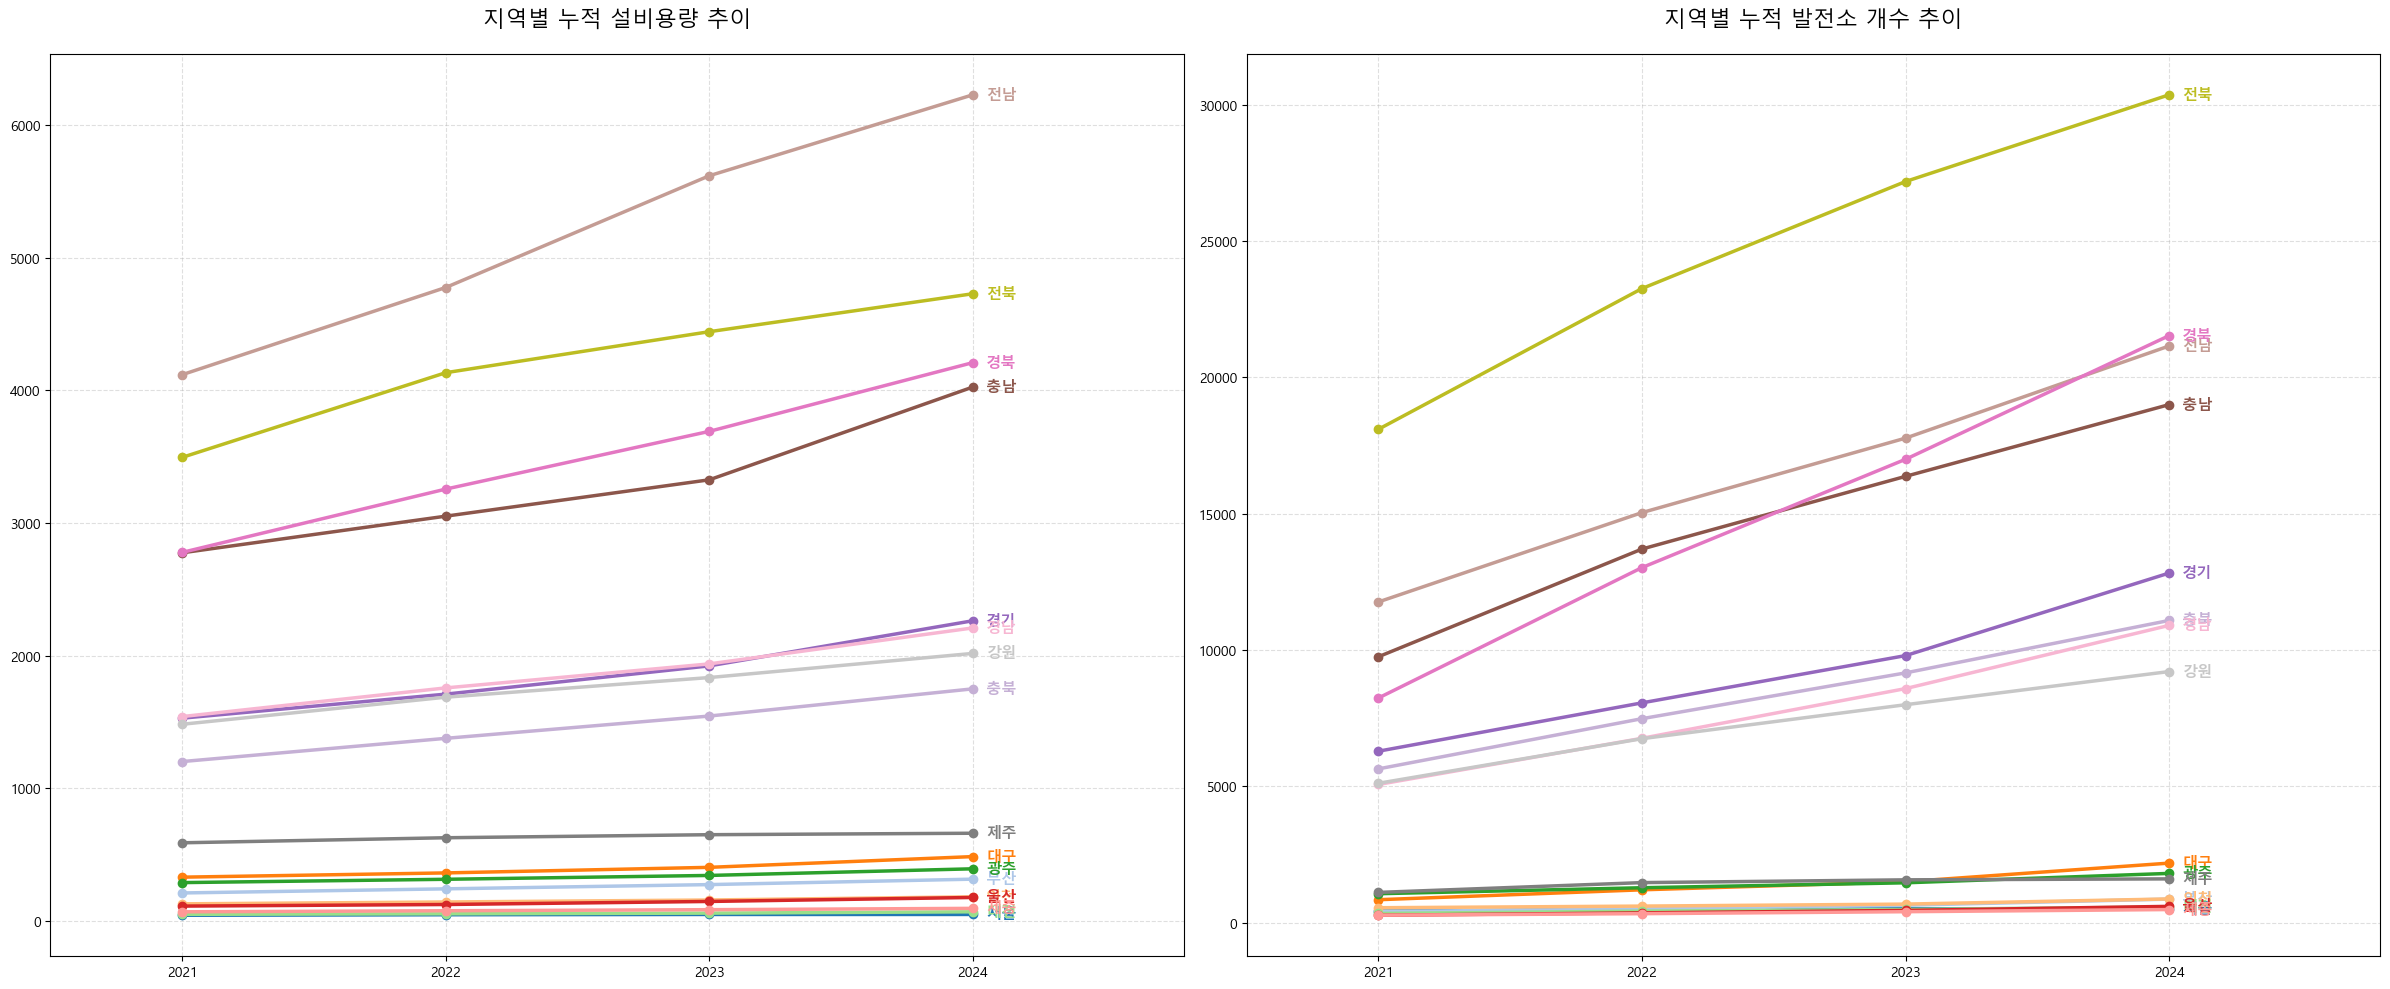

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 정제
df = pd.read_csv('./U통합자료+누적설비용량+누적발전소개수.csv', encoding='949')
df['누적 설비용량(MW)'] = df['누적 설비용량(MW)'].replace({',': ''}, regex=True).astype(float)
df['누적 설치발전소 개수'] = df['누적 설치발전소 개수'].replace({',': ''}, regex=True).astype(int)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 시각화 설정
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
palette = sns.color_palette("tab20", 17)
regions = df['구분'].unique()

# [함수] 선 끝에 텍스트를 붙이는 함수
def add_labels(ax, df_plot, target_col):
    for i, region in enumerate(regions):
        # 해당 지역의 데이터만 추출
        region_data = df_plot[df_plot['구분'] == region].sort_values('연도')
        line_color = palette[i]
        
        # 선 그리기
        ax.plot(region_data['연도'], region_data[target_col], 
                marker='o', color=line_color, linewidth=2.5, label=region)
        
        # 마지막 지점(2024년)의 좌표 찾기
        last_row = region_data[region_data['연도'] == 2024]
        if not last_row.empty:
            x = last_row['연도'].values[0]
            y = last_row[target_col].values[0]
            
            # 텍스트 추가 (x축에 약간의 여백 추가)
            ax.text(x + 0.05, y, region, color=line_color, 
                    va='center', fontweight='bold', fontsize=11)

# [좌측] 누적 설비용량 추이
add_labels(ax1, df, '누적 설비용량(MW)')
ax1.set_title('지역별 누적 설비용량 추이', fontsize=16, pad=20)
ax1.set_xlim(2020.5, 2024.8) # 이름이 들어갈 공간 확보
ax1.set_xticks([2021, 2022, 2023, 2024])
ax1.grid(True, linestyle='--', alpha=0.4)

# [우측] 누적 발전소 개수 추이
add_labels(ax2, df, '누적 설치발전소 개수')
ax2.set_title('지역별 누적 발전소 개수 추이', fontsize=16, pad=20)
ax2.set_xlim(2020.5, 2024.8) # 이름이 들어갈 공간 확보
ax2.set_xticks([2021, 2022, 2023, 2024])
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

# 1. 데이터 로드
df = pd.read_csv('./U통합자료+누적설비용량+누적발전소개수.csv', encoding='949')

# 2. 전처리 (숫자형 변환)
df['누적 설비용량(MW)'] = df['누적 설비용량(MW)'].replace({',': ''}, regex=True).astype(float)
df['합계'] = df['합계'].replace({',': ''}, regex=True).astype(float)

# 3. 이용률 계산 (윤년 보정 로직 포함)
# 2024년은 8784시간, 그 외는 8760시간 적용
df['이용률(%)'] = df.apply(
    lambda x: (x['합계'] / (x['누적 설비용량(MW)'] * (8784 if x['연도'] == 2024 else 8760))) * 100, 
    axis=1
)

# 4. 연도별 순위 테이블 생성
years = [2021, 2022, 2023, 2024]
final_table = pd.DataFrame()

for year in years:
    yearly_data = df[df['연도'] == year][['구분', '이용률(%)']].sort_values(by='이용률(%)', ascending=False)
    yearly_data = yearly_data.reset_index(drop=True)
    yearly_data.index = yearly_data.index + 1  
    
    col_name = f"{year}년"
    # 문자열 포맷팅으로 결과 정리
    temp_series = yearly_data.apply(lambda x: f"{x['구분']} ({x['이용률(%)']:.2f}%)", axis=1)
    final_table[col_name] = temp_series

# 5. 결과 출력 및 저장
print(final_table)
final_table.to_csv('태양광_효율_순위_결과_최종.csv', index=False, encoding='utf-8-sig')

          2021년        2022년        2023년        2024년
1   서울 (14.52%)  전북 (15.21%)  전북 (14.70%)  전북 (14.56%)
2   전남 (13.87%)  전남 (14.77%)  전남 (14.06%)  서울 (14.15%)
3   전북 (13.64%)  서울 (14.61%)  서울 (13.92%)  전남 (14.10%)
4   강원 (13.32%)  강원 (13.77%)  강원 (13.62%)  강원 (13.35%)
5   충남 (12.37%)  충남 (13.37%)  충남 (12.96%)  충남 (13.18%)
6   제주 (12.02%)  제주 (13.11%)  경북 (12.75%)  경북 (12.72%)
7   충북 (11.73%)  경남 (12.67%)  경남 (12.38%)  충북 (12.32%)
8   경남 (11.31%)  경북 (12.64%)  충북 (12.35%)  경남 (12.31%)
9   경북 (11.17%)  충북 (12.46%)  제주 (12.32%)  제주 (11.82%)
10  세종 (11.15%)  대전 (11.82%)  대전 (11.50%)  대전 (11.80%)
11  인천 (10.85%)  광주 (11.73%)  세종 (11.37%)  광주 (11.27%)
12  광주 (10.69%)  세종 (11.20%)  광주 (11.06%)  경기 (11.26%)
13  대전 (10.15%)  대구 (10.72%)  부산 (10.79%)  대구 (11.25%)
14   경기 (9.98%)  인천 (10.70%)  대구 (10.76%)  부산 (11.24%)
15   부산 (9.75%)  경기 (10.68%)  경기 (10.71%)  세종 (11.22%)
16   울산 (9.58%)  울산 (10.46%)  인천 (10.34%)  인천 (10.99%)
17   대구 (9.47%)  부산 (10.31%)   울산 (9.61%)  울산 (10.39%)


In [13]:
import folium

# 1. 지도 초기화 (한국 중심부)
m = folium.Map(location=[36.3, 127.8], zoom_start=7, tiles='cartodbpositron')

# 2. 17개 시도별 데이터 및 전략 정의
# 그룹 1: 풍력/하이브리드 중심 (울산, 제주) -> Blue
# 그룹 2: 태양광 최적화 중심 (나머지 15개 시도) -> Orange
region_data = [
    {"name": "서울", "coord": [37.5665, 126.9780], "type": "solar", "strategy": "옥상·건물형 태양광 집중, 효율 높은 모듈 적용"},
    {"name": "부산", "coord": [35.1796, 129.0756], "type": "solar", "strategy": "해상 태양광 검토, 방습/방식 모듈 적용"},
    {"name": "대구", "coord": [35.8714, 128.6014], "type": "solar", "strategy": "지붕·주차장 태양광 집중, 고효율 모듈 설치"},
    {"name": "인천", "coord": [37.4563, 126.7052], "type": "solar", "strategy": "산단 지붕형 태양광, 폐부지 활용"},
    {"name": "광주", "coord": [35.1595, 126.8526], "type": "solar", "strategy": "학교·공공시설 지붕형, 효율 모듈 적용"},
    {"name": "대전", "coord": [36.3504, 127.3845], "type": "solar", "strategy": "주거·공공시설 지붕형, 계절별 효율 최적화"},
    {"name": "울산", "coord": [35.5384, 129.3114], "type": "hybrid", "strategy": "풍력 중심 전략, 해상/육상 풍력단지 확충"},
    {"name": "세종", "coord": [36.4800, 127.2890], "type": "solar", "strategy": "공공건물 옥상 태양광, 효율 모듈 우선 적용"},
    {"name": "경기", "coord": [37.2751, 127.0096], "type": "solar", "strategy": "옥상 태양광 집중, 데이터 기반 효율 관리"},
    {"name": "강원", "coord": [37.8854, 127.7298], "type": "solar", "strategy": "산지 태양광 검토, 발전량 예측 기반 설치"},
    {"name": "충북", "coord": [36.6350, 127.4912], "type": "solar", "strategy": "농촌·주거지 집중, 영농형 태양광(Agri-PV)"},
    {"name": "충남", "coord": [36.6588, 126.6728], "type": "solar", "strategy": "농촌·산단 태양광 확충, 효율 중심 모듈"},
    {"name": "전북", "coord": [35.8242, 127.1480], "type": "solar", "strategy": "농촌형 태양광, Agri-PV, 계절별 최적화"},
    {"name": "전남", "coord": [34.8161, 126.4629], "type": "solar", "strategy": "농지·유휴지 태양광 + 해상 가능성 검토"},
    {"name": "경북", "coord": [36.5760, 128.5056], "type": "solar", "strategy": "농지·산지 태양광, 설치 위치 최적화"},
    {"name": "경남", "coord": [35.2377, 128.6922], "type": "solar", "strategy": "유휴 부지/산지/해안 태양광 검토"},
    {"name": "제주", "coord": [33.4996, 126.5312], "type": "hybrid", "strategy": "태양광·풍력 혼합(풍력 중심), 태양광 보조"}
]

# 3. 지도에 마커 추가
for loc in region_data:
    # 그룹에 따른 색상 및 아이콘 설정
    if loc['type'] == 'hybrid':
        color = 'blue'
        icon = 'info-sign' # 풍력/하이브리드 상징
        label = "풍력/하이브리드 중심"
    else:
        color = 'orange'
        icon = 'flash' # 태양광 상징
        label = "태양광 최적화 중심"

    # 팝업 내용 구성
    popup_html = f"""
    <div style="width:200px">
        <h4 style="margin-bottom:5px;">{loc['name']}</h4>
        <p style="font-size:12px;"><b>분류:</b> {label}</p>
        <p style="font-size:12px;"><b>전략:</b> {loc['strategy']}</p>
    </div>
    """
    
    folium.Marker(
        location=loc['coord'],
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{loc['name']} 전략 확인",
        icon=folium.Icon(color=color, icon=icon)
    ).add_to(m)

# 4. 지도 저장
m.save('korea_energy_strategy_map.html')

In [2]:
import folium

# 1. 지도 초기화 (대한민국 중심부)
m = folium.Map(location=[36.3, 127.8], zoom_start=7, tiles='cartodbpositron')

# 2. 지역별 데이터 정의 (작성하신 전략 기반)
# type_color: 도시형(orange), 해안/산단(blue), 영농/내륙(green), 청정거점(purple)
energy_strategies = [
    # 1. 도시형 에너지 자립 그룹
    {"name": "서울", "coord": [37.5665, 126.9780], "color": "orange", "icon": "bolt", "strategy": "<b>태양광 + BEMS</b><br>건물 BIPV 및 VPP 모델 구축"},
    {"name": "세종", "coord": [36.4800, 127.2890], "color": "orange", "icon": "bolt", "strategy": "<b>태양광 + EV 충전</b><br>주차장 태양광과 전기차 충전소 직결"},
    {"name": "대전", "coord": [36.3504, 127.3845], "color": "orange", "icon": "bolt", "strategy": "<b>태양광 + EV 충전</b><br>공공기관 지붕 활용 및 송전손실 최소화"},
    {"name": "대구", "coord": [35.8714, 128.6014], "color": "orange", "icon": "bolt", "strategy": "<b>고효율 태양광 + ESS</b><br>커뮤니티 에너지 저장 및 피크 대응"},
    {"name": "광주", "coord": [35.1595, 126.8526], "color": "orange", "icon": "bolt", "strategy": "<b>고효율 태양광 + ESS</b><br>낮 시간 저장 후 저녁 시간 방출 최적화"},
    
    # 2. 해안·산단 하이브리드 그룹
    {"name": "울산", "coord": [35.5384, 129.3114], "color": "blue", "icon": "tint", "strategy": "<b>부유식 해상풍력 + 그린수소</b><br>해풍 활용 및 산단 수소 트럭 연계"},
    {"name": "인천", "coord": [37.4563, 126.7052], "color": "blue", "icon": "tint", "strategy": "<b>해상 태양광 + 항만 풍력</b><br>유휴 해수면 활용 및 염해 강화 모듈"},
    {"name": "부산", "coord": [35.1796, 129.0756], "color": "blue", "icon": "tint", "strategy": "<b>해상 태양광 + 항만 풍력</b><br>항만 배후 부지 풍력 조합"},
    {"name": "경남", "coord": [35.2377, 128.6922], "color": "blue", "icon": "tint", "strategy": "<b>산단 지붕 태양광 + 수소 연료전지</b><br>공장 24시간 안정적 전력 공급"},
    
    # 3. 영농·내륙 복합 그룹
    {"name": "전북", "coord": [35.8242, 127.1480], "color": "green", "icon": "leaf", "strategy": "<b>영농형 태양광(Agri-PV)</b><br>작물 재배-전력 생산 병행 모델"},
    {"name": "충남", "coord": [36.6588, 126.6728], "color": "green", "icon": "leaf", "strategy": "<b>영농형 태양광 + 산단 확충</b><br>미세먼지 대비 보조 전원 확보"},
    {"name": "전남", "coord": [34.8161, 126.4629], "color": "green", "icon": "leaf", "strategy": "<b>염전/수상 태양광 + 해상 풍력</b><br>거대 에너지 섬 클러스터 구축"},
    {"name": "충북", "coord": [36.6350, 127.4912], "color": "green", "icon": "leaf", "strategy": "<b>내륙 태양광 + 소수력/바이오</b><br>축산 분뇨 바이오 가스 연계"},
    {"name": "경북", "coord": [36.5760, 128.5056], "color": "green", "icon": "leaf", "strategy": "<b>내륙 태양광 + 바이오 가스</b><br>기상 변동성 보완형 믹스"},
    {"name": "경기", "coord": [37.2751, 127.0096], "color": "green", "icon": "leaf", "strategy": "<b>옥상 태양광 + 스마트 그리드</b><br>산단 및 인구 밀집지 효율 관리"},
    
    # 4. 청정 에너지 거점 그룹
    {"name": "제주", "coord": [33.4996, 126.5312], "color": "purple", "icon": "cloud", "strategy": "<b>풍력(주) + 수소 버스</b><br>출력 제한 해소를 위한 P2G 모델"},
    {"name": "강원", "coord": [37.8854, 127.7298], "color": "purple", "icon": "cloud", "strategy": "<b>육상 풍력 + 수상 태양광</b><br>산바람-댐 태양광 상호보완"},
]

# 3. 지도에 마커 추가
for loc in energy_strategies:
    folium.Marker(
        location=loc['coord'],
        popup=folium.Popup(f"<b>{loc['name']}</b><br>{loc['strategy']}", max_width=300),
        tooltip=f"{loc['name']} 전략",
        icon=folium.Icon(color=loc['color'], icon=loc['icon'], prefix='fa')
    ).add_to(m)

# 4. 범례(Legend) 추가 (HTML을 이용한 커스텀)
legend_html = '''
     <div style="position: fixed; 
     bottom: 50px; left: 50px; width: 220px; height: 160px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; opacity: 0.8;
     padding: 10px; border-radius: 10px;">
     <b>에너지 그룹별 전략</b><br>
     <i class="fa fa-bolt" style="color:orange"></i> 도시형 에너지 자립<br>
     <i class="fa fa-tint" style="color:blue"></i> 해안·산단 하이브리드<br>
     <i class="fa fa-leaf" style="color:green"></i> 영농·내륙 복합<br>
     <i class="fa fa-cloud" style="color:purple"></i> 청정 에너지 거점<br>
     </div>
     '''
m.get_root().html.add_child(folium.Element(legend_html))

# 5. 저장
m.save('regional_energy_hybrid_strategy.html')

지역별 하이브리드 에너지 전략 (데이터 기반 분석)

📌 도시형 에너지 자립 그룹

🔹 서울
   전략: 건물 통합 태양광(BIPV) + VPP 빌딩 외벽/지붕 태양광과 가상발전소로 피크 대응
   📊 2026년 예측: 53.0 TWh | ESS: 29,061 MWh
   📈 2023-2025 추세: -11.9% (⚠️ 급감)

🔹 세종
   전략: 스마트시티 태양광 + V2G 공공건물 태양광과 전기차 양방향 충전
   📊 2026년 예측: 1.5 TWh | ESS: 841 MWh
   📈 2023-2025 추세: -8.6% (✓ 안정)

🔹 대전
   전략: 연구단지 태양광 + 마이크로그리드 대덕연구단지 분산형 에너지 실증
   📊 2026년 예측: 9.7 TWh | ESS: 5,310 MWh
   📈 2023-2025 추세: -11.9% (⚠️ 급감)

🔹 대구
   전략: 일조량 최적화 태양광 + ESS 높은 일사량 활용, 여름 피크 집중 대응
   📊 2026년 예측: 14.8 TWh | ESS: 8,103 MWh
   📈 2023-2025 추세: -13.4% (⚠️ 급감)

🔹 광주
   전략: 태양광 R&D 클러스터 + ESS 국가 태양광 산업단지 실증 및 상용화
   📊 2026년 예측: 8.8 TWh | ESS: 4,800 MWh
   📈 2023-2025 추세: -12.9% (⚠️ 급감)

📌 해안·산단 하이브리드 그룹

🔹 울산
   전략: ⚠️ 급감: 부유식 풍력 + 그린수소 석유화학 대체 에너지 긴급 확보
   📊 2026년 예측: 15.0 TWh | ESS: 8,245 MWh
   📈 2023-2025 추세: -20.2% (⚠️ 급감)

🔹 인천
   전략: 해상풍력 + 항만 태양광 서해 풍력단지와 물류센터 지붕 태양광
   📊 2026년 예측: 22.2 TWh | ESS: 12,152 MWh
   📈 2023-2025 추세: -14.6% (⚠️ 급감)

🔹 부산
   전략: 해상풍력 + 수소항만 부유식 풍력과 수소선박 연료 공급망
  

C:\Users\82104\AppData\Local\Temp\ipykernel_6756\2831925493.py:429: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\82104\AppData\Local\Temp\ipykernel_6756\2831925493.py:429: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\82104\AppData\Local\Temp\ipykernel_6756\2831925493.py:430: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig('regional_energy_strategy_analysis.png', dpi=300, bbox_inches='tight')
C:\Users\82104\AppData\Local\Temp\ipykernel_6756\2831925493.py:430: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.savefig('regional_energy_strategy_analysis.png', dpi=300, bbox_inches='tight')


✅ 분석 그래프가 'regional_energy_strategy_analysis.png'로 저장되었습니다.



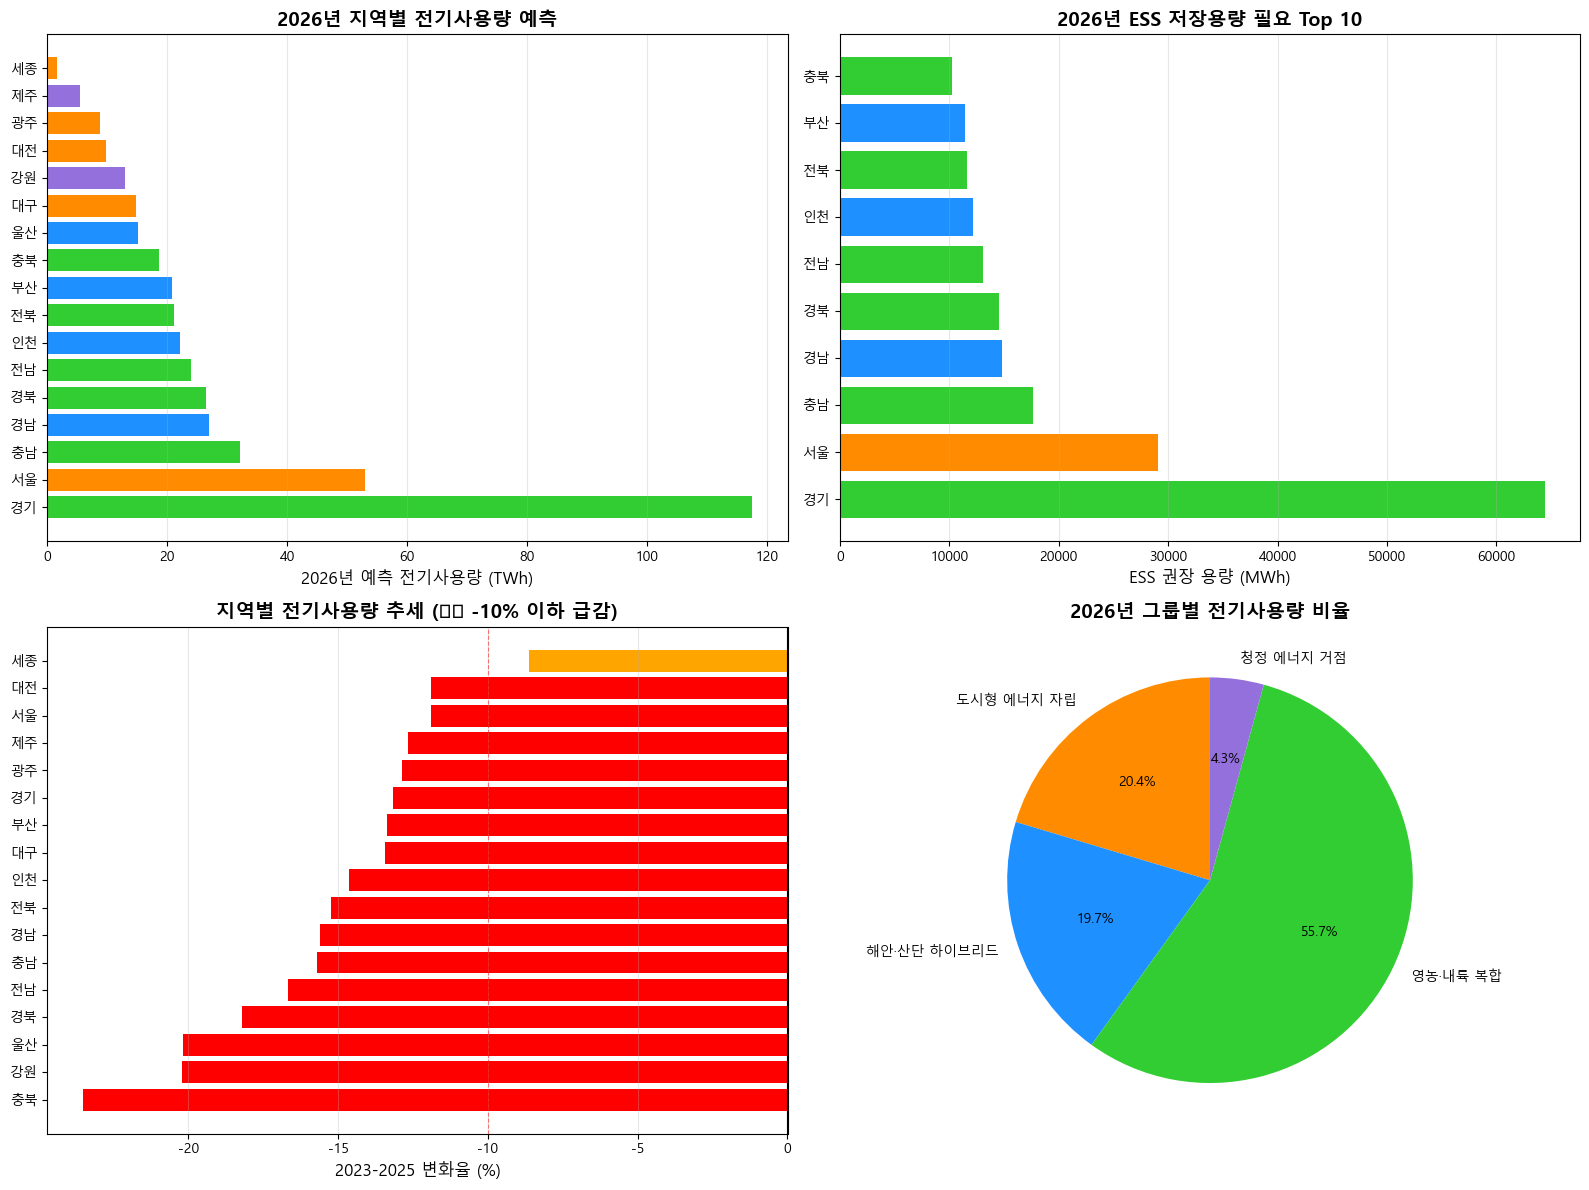

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import folium
from folium import plugins

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================================
# 1. 머신러닝 예측 부분
# ============================================================================

# 원본 데이터 (TWh 단위)
data = {
    'year': [2021, 2022, 2023, 2024, 2025],
    '서울': [47.3, 48.79, 49.22, 41.37, 43.36],
    '부산': [21.07, 21.49, 21.56, 18.62, 18.68],
    '대구': [15.44, 16.04, 16.29, 14.37, 14.1],
    '인천': [24.9, 25.51, 25.88, 22.86, 22.09],
    '광주': [8.97, 9.12, 9.08, 7.92, 7.91],
    '대전': [9.75, 10.02, 9.92, 8.78, 8.74],
    '울산': [33.59, 32.92, 31.83, 30.84, 25.41],
    '경기': [133.45, 140.53, 140.31, 129.45, 121.84],
    '강원': [16.81, 17.33, 17.11, 14.89, 13.65],
    '충북': [28.4, 29.41, 29.45, 25.65, 22.52],
    '충남': [48.8, 50.26, 49.63, 47.68, 41.83],
    '전북': [21.49, 21.84, 21.44, 18.11, 18.17],
    '전남': [33.49, 34.67, 33.98, 31.78, 28.31],
    '경북': [43.92, 44.26, 43.73, 41.14, 35.77],
    '경남': [35.73, 36.19, 36.35, 33.27, 30.68],
    '제주': [5.69, 6.05, 6.08, 5.51, 5.31],
    '세종': [4.3, 3.18, 3.94, 3.71, 3.6]
}

df = pd.DataFrame(data)
regions = [col for col in df.columns if col != 'year']

# 3차 다항식 함수
def polynomial_3(x, a, b, c, d):
    return a + b*x + c*x**2 + d*x**3

# 각 지역별 예측
predictions = {}
model_metrics = {}

for region in regions:
    years = df['year'].values
    values = df[region].values
    
    # 데이터 정규화
    year_mean = years.mean()
    year_std = years.std()
    normalized_years = (years - year_mean) / year_std
    
    try:
        params, _ = curve_fit(polynomial_3, normalized_years, values, maxfev=5000)
        
        # 2026년 예측
        future_year = 2026
        normalized_future = (future_year - year_mean) / year_std
        future_prediction = polynomial_3(normalized_future, *params)
        future_prediction = max(0, future_prediction)
        
        # R² 계산
        predicted_values = polynomial_3(normalized_years, *params)
        ss_res = np.sum((values - predicted_values) ** 2)
        ss_tot = np.sum((values - values.mean()) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        
        # 최근 추세
        recent_trend = ((values[-1] - values[-3]) / values[-3]) * 100
        
        predictions[region] = {
            'pred_2026': future_prediction,
            'r2': r2,
            'trend': recent_trend
        }
        
        # ESS 계산
        daily_usage_gwh = (future_prediction * 1000) / 365
        ess_recommended = int(daily_usage_gwh * 0.20 * 1000)  # MWh
        
        predictions[region]['ess'] = ess_recommended
        
    except Exception as e:
        print(f"{region} 예측 실패: {e}")

# ============================================================================
# 2. 지역별 하이브리드 에너지 전략 정의
# ============================================================================

regions_strategy = [
    # 1. 도시형 에너지 자립 그룹
    {
        "name": "서울", 
        "coord": [37.5665, 126.9780], 
        "color": "orange", 
        "icon": "bolt",
        "group": "도시형 에너지 자립",
        "strategy": "<b>건물 통합 태양광(BIPV) + VPP</b><br>빌딩 외벽/지붕 태양광과 가상발전소로 피크 대응",
        "pred_2026": predictions['서울']['pred_2026'],
        "ess": predictions['서울']['ess'],
        "trend": predictions['서울']['trend']
    },
    {
        "name": "세종", 
        "coord": [36.4800, 127.2890], 
        "color": "orange", 
        "icon": "bolt",
        "group": "도시형 에너지 자립",
        "strategy": "<b>스마트시티 태양광 + V2G</b><br>공공건물 태양광과 전기차 양방향 충전",
        "pred_2026": predictions['세종']['pred_2026'],
        "ess": predictions['세종']['ess'],
        "trend": predictions['세종']['trend']
    },
    {
        "name": "대전", 
        "coord": [36.3504, 127.3845], 
        "color": "orange", 
        "icon": "bolt",
        "group": "도시형 에너지 자립",
        "strategy": "<b>연구단지 태양광 + 마이크로그리드</b><br>대덕연구단지 분산형 에너지 실증",
        "pred_2026": predictions['대전']['pred_2026'],
        "ess": predictions['대전']['ess'],
        "trend": predictions['대전']['trend']
    },
    {
        "name": "대구", 
        "coord": [35.8714, 128.6014], 
        "color": "orange", 
        "icon": "bolt",
        "group": "도시형 에너지 자립",
        "strategy": "<b>일조량 최적화 태양광 + ESS</b><br>높은 일사량 활용, 여름 피크 집중 대응",
        "pred_2026": predictions['대구']['pred_2026'],
        "ess": predictions['대구']['ess'],
        "trend": predictions['대구']['trend']
    },
    {
        "name": "광주", 
        "coord": [35.1595, 126.8526], 
        "color": "orange", 
        "icon": "bolt",
        "group": "도시형 에너지 자립",
        "strategy": "<b>태양광 R&D 클러스터 + ESS</b><br>국가 태양광 산업단지 실증 및 상용화",
        "pred_2026": predictions['광주']['pred_2026'],
        "ess": predictions['광주']['ess'],
        "trend": predictions['광주']['trend']
    },
    
    # 2. 해안·산단 하이브리드 그룹
    {
        "name": "울산", 
        "coord": [35.5384, 129.3114], 
        "color": "blue", 
        "icon": "tint",
        "group": "해안·산단 하이브리드",
        "strategy": "<b>⚠️ 급감: 부유식 풍력 + 그린수소</b><br>석유화학 대체 에너지 긴급 확보",
        "pred_2026": predictions['울산']['pred_2026'],
        "ess": predictions['울산']['ess'],
        "trend": predictions['울산']['trend']
    },
    {
        "name": "인천", 
        "coord": [37.4563, 126.7052], 
        "color": "blue", 
        "icon": "tint",
        "group": "해안·산단 하이브리드",
        "strategy": "<b>해상풍력 + 항만 태양광</b><br>서해 풍력단지와 물류센터 지붕 태양광",
        "pred_2026": predictions['인천']['pred_2026'],
        "ess": predictions['인천']['ess'],
        "trend": predictions['인천']['trend']
    },
    {
        "name": "부산", 
        "coord": [35.1796, 129.0756], 
        "color": "blue", 
        "icon": "tint",
        "group": "해안·산단 하이브리드",
        "strategy": "<b>해상풍력 + 수소항만</b><br>부유식 풍력과 수소선박 연료 공급망",
        "pred_2026": predictions['부산']['pred_2026'],
        "ess": predictions['부산']['ess'],
        "trend": predictions['부산']['trend']
    },
    {
        "name": "경남", 
        "coord": [35.2377, 128.6922], 
        "color": "blue", 
        "icon": "tint",
        "group": "해안·산단 하이브리드",
        "strategy": "<b>산단 태양광 + 연료전지</b><br>조선·기계 산업단지 24시간 안정 공급",
        "pred_2026": predictions['경남']['pred_2026'],
        "ess": predictions['경남']['ess'],
        "trend": predictions['경남']['trend']
    },
    
    # 3. 영농·내륙 복합 그룹
    {
        "name": "전북", 
        "coord": [35.8242, 127.1480], 
        "color": "green", 
        "icon": "leaf",
        "group": "영농·내륙 복합",
        "strategy": "<b>⚠️ 영농형 태양광 + 풍력</b><br>새만금 대규모 재생에너지 단지 조속 구축",
        "pred_2026": predictions['전북']['pred_2026'],
        "ess": predictions['전북']['ess'],
        "trend": predictions['전북']['trend']
    },
    {
        "name": "충남", 
        "coord": [36.6588, 126.6728], 
        "color": "green", 
        "icon": "leaf",
        "group": "영농·내륙 복합",
        "strategy": "<b>⚠️ 대규모 태양광 + 해상풍력</b><br>석탄발전 축소 대응 긴급 필요",
        "pred_2026": predictions['충남']['pred_2026'],
        "ess": predictions['충남']['ess'],
        "trend": predictions['충남']['trend']
    },
    {
        "name": "전남", 
        "coord": [34.8161, 126.4629], 
        "color": "green", 
        "icon": "leaf",
        "group": "영농·내륙 복합",
        "strategy": "<b>⚠️ 신안 해상풍력 + 수상태양광</b><br>전국 최대 재생에너지 생산기지 구축",
        "pred_2026": predictions['전남']['pred_2026'],
        "ess": predictions['전남']['ess'],
        "trend": predictions['전남']['trend']
    },
    {
        "name": "충북", 
        "coord": [36.6350, 127.4912], 
        "color": "green", 
        "icon": "leaf",
        "group": "영농·내륙 복합",
        "strategy": "<b>⚠️ 내륙 태양광 + 바이오</b><br>수요 급감 대응 분산형 전원 최적화",
        "pred_2026": predictions['충북']['pred_2026'],
        "ess": predictions['충북']['ess'],
        "trend": predictions['충북']['trend']
    },
    {
        "name": "경북", 
        "coord": [36.5760, 128.5056], 
        "color": "green", 
        "icon": "leaf",
        "group": "영농·내륙 복합",
        "strategy": "<b>⚠️ 태양광 + 소수력 + ESS</b><br>산업 이탈 대비 에너지 전환 가속",
        "pred_2026": predictions['경북']['pred_2026'],
        "ess": predictions['경북']['ess'],
        "trend": predictions['경북']['trend']
    },
    {
        "name": "경기", 
        "coord": [37.2751, 127.0096], 
        "color": "green", 
        "icon": "leaf",
        "group": "영농·내륙 복합",
        "strategy": "<b>⚠️ 분산형 태양광 + 스마트그리드</b><br>전국 최대 수요 안정화 긴급 대응",
        "pred_2026": predictions['경기']['pred_2026'],
        "ess": predictions['경기']['ess'],
        "trend": predictions['경기']['trend']
    },
    
    # 4. 청정 에너지 거점 그룹
    {
        "name": "제주", 
        "coord": [33.4996, 126.5312], 
        "color": "purple", 
        "icon": "cloud",
        "group": "청정 에너지 거점",
        "strategy": "<b>풍력 100% + P2G</b><br>출력제한 문제 해결 위한 수소 전환",
        "pred_2026": predictions['제주']['pred_2026'],
        "ess": predictions['제주']['ess'],
        "trend": predictions['제주']['trend']
    },
    {
        "name": "강원", 
        "coord": [37.8854, 127.7298], 
        "color": "purple", 
        "icon": "cloud",
        "group": "청정 에너지 거점",
        "strategy": "<b>⚠️ 풍력 + 수상태양광 + 양수발전</b><br>관광 연계 청정 에너지 모델",
        "pred_2026": predictions['강원']['pred_2026'],
        "ess": predictions['강원']['ess'],
        "trend": predictions['강원']['trend']
    },
]

# ============================================================================
# 3. 결과 출력
# ============================================================================

print("="*100)
print("지역별 하이브리드 에너지 전략 (데이터 기반 분석)")
print("="*100)

# 그룹별로 정리
groups = {}
for region in regions_strategy:
    group_name = region['group']
    if group_name not in groups:
        groups[group_name] = []
    groups[group_name].append(region)

for group_name, group_regions in groups.items():
    print(f"\n{'='*100}")
    print(f"📌 {group_name} 그룹")
    print(f"{'='*100}")
    
    for region in group_regions:
        status = "⚠️ 급감" if region['trend'] < -10 else "✓ 안정"
        print(f"\n🔹 {region['name']}")
        print(f"   전략: {region['strategy'].replace('<b>', '').replace('</b>', '').replace('<br>', ' ')}")
        print(f"   📊 2026년 예측: {region['pred_2026']:.1f} TWh | ESS: {region['ess']:,} MWh")
        print(f"   📈 2023-2025 추세: {region['trend']:.1f}% ({status})")

# ============================================================================
# 4. 지도 시각화
# ============================================================================

# Folium 지도 생성
m = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles='OpenStreetMap')

# 마커 추가
for region in regions_strategy:
    # 팝업 내용
    popup_html = f"""
    <div style="width:300px">
        <h4 style="margin:0 0 10px 0">{region['name']}</h4>
        <p style="margin:5px 0"><b>전략 그룹:</b> {region['group']}</p>
        <hr style="margin:10px 0">
        {region['strategy']}
        <hr style="margin:10px 0">
        <p style="margin:5px 0"><b>2026년 예측:</b> {region['pred_2026']:.1f} TWh</p>
        <p style="margin:5px 0"><b>ESS 권장:</b> {region['ess']:,} MWh</p>
    </div>
    """
    
    folium.Marker(
        location=region['coord'],
        popup=folium.Popup(popup_html, max_width=300),
        icon=folium.Icon(color=region['color'], icon=region['icon'], prefix='fa'),
        tooltip=f"{region['name']} - {region['pred_2026']:.1f} TWh"
    ).add_to(m)

# 범례 추가
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; left: 50px; width: 300px; height: auto; 
            background-color: white; z-index:9999; font-size:14px;
            border:2px solid grey; border-radius: 5px; padding: 10px">
<h4 style="margin:0 0 10px 0">하이브리드 에너지 전략 그룹</h4>
<p><i class="fa fa-bolt" style="color:orange"></i> 도시형 에너지 자립</p>
<p><i class="fa fa-tint" style="color:blue"></i> 해안·산단 하이브리드</p>
<p><i class="fa fa-leaf" style="color:green"></i> 영농·내륙 복합</p>
<p><i class="fa fa-cloud" style="color:purple"></i> 청정 에너지 거점</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# 지도 저장
m.save('regional_energy_strategy_map.html')
print(f"\n{'='*100}")
print("✅ 지도가 'regional_energy_strategy_map.html'로 저장되었습니다.")
print(f"{'='*100}")

# ============================================================================
# 5. 추가 분석 그래프
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 2026년 예측값 비교
ax1 = axes[0, 0]
regions_sorted = sorted(regions_strategy, key=lambda x: x['pred_2026'], reverse=True)
names = [r['name'] for r in regions_sorted]
values = [r['pred_2026'] for r in regions_sorted]
colors_map = {'orange': '#ff8c00', 'blue': '#1e90ff', 'green': '#32cd32', 'purple': '#9370db'}
bar_colors = [colors_map[r['color']] for r in regions_sorted]
ax1.barh(names, values, color=bar_colors)
ax1.set_xlabel('2026년 예측 전기사용량 (TWh)', fontsize=12)
ax1.set_title('2026년 지역별 전기사용량 예측', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# 2. ESS 용량 비교
ax2 = axes[0, 1]
ess_sorted = sorted(regions_strategy, key=lambda x: x['ess'], reverse=True)[:10]
ess_names = [r['name'] for r in ess_sorted]
ess_values = [r['ess'] for r in ess_sorted]
ess_colors = [colors_map[r['color']] for r in ess_sorted]
ax2.barh(ess_names, ess_values, color=ess_colors)
ax2.set_xlabel('ESS 권장 용량 (MWh)', fontsize=12)
ax2.set_title('2026년 ESS 저장용량 필요 Top 10', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# 3. 추세 분석
ax3 = axes[1, 0]
trend_data = [(r['name'], r['trend']) for r in regions_strategy]
trend_data.sort(key=lambda x: x[1])
trend_names = [t[0] for t in trend_data]
trend_values = [t[1] for t in trend_data]
trend_colors = ['red' if v < -10 else 'green' if v > 0 else 'orange' for v in trend_values]
ax3.barh(trend_names, trend_values, color=trend_colors)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax3.axvline(x=-10, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax3.set_xlabel('2023-2025 변화율 (%)', fontsize=12)
ax3.set_title('지역별 전기사용량 추세 (⚠️ -10% 이하 급감)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# 4. 그룹별 합계
ax4 = axes[1, 1]
group_totals = {}
for region in regions_strategy:
    group = region['group']
    if group not in group_totals:
        group_totals[group] = 0
    group_totals[group] += region['pred_2026']

group_names = list(group_totals.keys())
group_values = list(group_totals.values())
group_colors_list = ['#ff8c00', '#1e90ff', '#32cd32', '#9370db']
ax4.pie(group_values, labels=group_names, autopct='%1.1f%%', startangle=90, colors=group_colors_list)
ax4.set_title('2026년 그룹별 전기사용량 비율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('regional_energy_strategy_analysis.png', dpi=300, bbox_inches='tight')
print("✅ 분석 그래프가 'regional_energy_strategy_analysis.png'로 저장되었습니다.")
print(f"{'='*100}\n")

plt.show()